### Setup
Loading the libraries and company universe: 35 U.S. retailers, covering 
2019–2023 10-K filings.


In [60]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
from edgar import Company, set_identity

set_identity("Akeem Akinyemi jumkeem04@gmail.com")

company_df = pd.read_csv("../data/processed/company_universe.csv")
print(f"Total companies: {len(company_df)}")
company_df.head()

Total companies: 35


,ticker,company_name
0,WMT,Walmart
1,TGT,Target
2,COST,Costco
3,BJ,BJ's Wholesale
4,HD,Home Depot


### Fetching Risk Factors sections
Using edgartools to pull the actual 10-K filings and extract the Risk 
Factors section for each company across 2019–2023. A few companies were 
delisted or renamed since their filings, so their CIK numbers are used 
directly instead of ticker symbols.

In [61]:
def get_filings_in_range(company_obj, start_year=2019, end_year=2023):
    """Filter a company's 10-K filings to just those filed within the target years."""
    all_10ks = company_obj.get_filings(form="10-K")
    return [f for f in all_10ks if start_year <= f.filing_date.year <= end_year]


cik_fallbacks = {
    "BBBY": "0000886158",
    "JWN": "0000072333",
    "GPS": "0000039911",
    "WBA": "0001618921",
}

results = []
extraction_failures = []

for ticker in company_df["ticker"]:
    try:
        company = Company(cik_fallbacks.get(ticker, ticker))
        filings = get_filings_in_range(company)

        if len(filings) == 0:
            extraction_failures.append((ticker, "no filings found in range"))
            continue

        for filing in filings:
            try:
                tenk = filing.obj()
                risk_text = tenk.risk_factors

                if not risk_text or len(risk_text) < 1000:
                    extraction_failures.append((ticker, f"{filing.filing_date}: too short or empty"))
                    continue

                results.append({
                    "ticker": ticker,
                    "filing_year": filing.filing_date.year,
                    "accession_number": filing.accession_no,
                    "risk_text": risk_text,
                    "risk_text_length": len(risk_text),
                })
            except Exception as e:
                extraction_failures.append((ticker, f"{filing.filing_date}: {e}"))

        print(f"{ticker}: processed")
        time.sleep(0.3)

    except Exception as e:
        extraction_failures.append((ticker, f"company lookup failed: {e}"))
        print(f"{ticker}: FAILED — {e}")

print(f"\nTotal successful extractions: {len(results)}")
print(f"Total failures: {len(extraction_failures)}")

WMT: processed
TGT: processed
COST: processed
BJ: processed
HD: processed
LOW: processed
M: processed
JWN: processed
KSS: processed
TJX: processed
ROST: processed
BURL: processed
GPS: processed
ANF: processed
URBN: processed
AEO: processed
BBY: processed
GME: processed
DKS: processed
WSM: processed
RH: processed
BBBY: processed
ETSY: processed
W: processed
CHWY: processed
CVNA: processed
DG: processed
DLTR: processed
FIVE: processed
KR: processed
ACI: processed
WBA: processed
CVS: processed
AZO: processed
ORLY: processed

Total successful extractions: 174
Total failures: 7


### Deduplicating to one filing per company per year
A few companies had amended or duplicate filings within the same year. 
Keeping only the first valid filing per company per year.

In [62]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(["ticker", "filing_year"]).drop_duplicates(
    subset=["ticker", "filing_year"], keep="first"
).reset_index(drop=True)

print(f"Final row count: {len(results_df)}")
results_df.groupby("ticker")["filing_year"].count().describe()

Final row count: 174


count    35.000000
mean      4.971429
std       0.169031
min       4.000000
25%       5.000000
50%       5.000000
75%       5.000000
max       5.000000
Name: filing_year, dtype: float64

### Validation
Checking completeness and scanning every company's most recent filing to 
confirm the extracted text is genuine risk-factor content.

In [63]:
years_per_company = results_df.groupby("ticker")["filing_year"].agg(["count", "nunique"])
print(f"Companies with fewer than 5 years: {(years_per_company['count'] < 5).sum()}")
print(f"Companies with duplicate years: {(years_per_company['count'] != years_per_company['nunique']).sum()}")

print(f"\nLength distribution:")
print(results_df["risk_text_length"].describe())

print("\n--- Spot check: first 150 chars of each company's 2023 filing ---")
latest = results_df[results_df["filing_year"] == 2023]
for _, row in latest.iterrows():
    print(f"\n{row['ticker']}: {row['risk_text'][:150]}")

Companies with fewer than 5 years: 1
Companies with duplicate years: 0

Length distribution:
count       174.000000
mean      69214.103448
std       40048.538541
min       14907.000000
25%       40219.750000
50%       56520.000000
75%       83312.250000
max      184611.000000
Name: risk_text_length, dtype: float64

--- Spot check: first 150 chars of each company's 2023 filing ---

ACI: Item 1A - Risk Factors

There are risks and uncertainties that can affect our business. The most significant risk factors are discussed below. The fol

AEO: Item 1A. Risk Factors 

  Macroeconomic and Industry Risks

  Global economic conditions and the effect of economic pressures and other business facto

ANF: Item 1A. Risk Factors

Investing in our securities involves risk. The following risk factors should be read carefully in connection with evaluating ou

AZO: Item 1A. Risk Factors

Our business is subject to a variety of risks and uncertainties. The risks and uncertainties described below could ma

### Saving the extracted data

In [64]:
results_df.to_csv("../data/processed/risk_sections_raw.csv", index=False)
print(f"Saved {len(results_df):,} rows to data/processed/risk_sections_raw.csv")

Saved 174 rows to data/processed/risk_sections_raw.csv


In [66]:
results_df.head()


,ticker,filing_year,accession_number,risk_text,risk_text_length
0,ACI,2019,0001646972-19-000036,Item 1A - Risk Factors\n\nThere are risks and ...,58614
1,ACI,2020,0001646972-20-000022,Item 1A - Risk Factors\n\nThere are risks and ...,76860
2,ACI,2021,0001646972-21-000026,Item 1A - Risk Factors\n\nThere are risks and ...,104545
3,ACI,2022,0001646972-22-000031,Item 1A - Risk Factors\n\nThere are risks and ...,100555
4,ACI,2023,0001646972-23-000045,Item 1A - Risk Factors\n\nThere are risks and ...,81580


### Measuring risk language change year over year
For each company, comparing consecutive years' risk sections: how much the 
word count changed, and how different the actual wording is using TF-IDF 
cosine similarity, which captures wording change independent of length.

In [67]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

results_df_sorted = results_df.sort_values(["ticker", "filing_year"]).reset_index(drop=True)

change_records = []

for ticker in results_df_sorted["ticker"].unique():
    company_rows = results_df_sorted[results_df_sorted["ticker"] == ticker].reset_index(drop=True)

    for i in range(len(company_rows) - 1):
        year_a = company_rows.loc[i, "filing_year"]
        year_b = company_rows.loc[i + 1, "filing_year"]
        text_a = company_rows.loc[i, "risk_text"]
        text_b = company_rows.loc[i + 1, "risk_text"]

        len_a, len_b = len(text_a.split()), len(text_b.split())
        word_count_change_pct = (len_b - len_a) / len_a * 100

        vectorizer = TfidfVectorizer(stop_words="english", max_features=5000)
        tfidf_matrix = vectorizer.fit_transform([text_a, text_b])
        similarity = cosine_similarity(tfidf_matrix[0], tfidf_matrix[1])[0][0]

        change_records.append({
            "ticker": ticker,
            "year_from": year_a,
            "year_to": year_b,
            "word_count_change_pct": word_count_change_pct,
            "text_similarity": similarity,
            "text_change_score": 1 - similarity,
        })

change_df = pd.DataFrame(change_records)
print(f"Total year-over-year comparisons: {len(change_df)}")
change_df.head(10)

Total year-over-year comparisons: 139


,ticker,year_from,year_to,word_count_change_pct,text_similarity,text_change_score
0,ACI,2019,2020,32.327343,0.932875,0.067125
1,ACI,2020,2021,37.601435,0.742539,0.257461
2,ACI,2021,2022,-4.090881,0.969346,0.030654
3,ACI,2022,2023,-20.000000,0.871006,0.128994
4,AEO,2019,2020,7.981410,0.963702,0.036298
5,AEO,2020,2021,26.459581,0.941283,0.058717
6,AEO,2021,2022,53.714117,0.940573,0.059427
7,AEO,2022,2023,-2.849442,0.977309,0.022691
8,ANF,2019,2020,19.238593,0.887066,0.112934
9,ANF,2020,2021,37.862540,0.968294,0.031706


In [68]:
change_df.to_csv("../data/processed/risk_change_metrics.csv", index=False)
print(f"Saved {len(change_df):,} rows to data/processed/risk_change_metrics.csv")

Saved 139 rows to data/processed/risk_change_metrics.csv


### Visualizing risk-language change by year
Checking whether the average change score shows any meaningful pattern 
across the 2019-2023 period, and which companies show the most change.

In [69]:
avg_change_by_year = change_df.groupby(["year_from", "year_to"])["text_change_score"].agg(["mean", "std", "count"])
print(avg_change_by_year)

top_changes = change_df.sort_values("text_change_score", ascending=False).head(10)
print("\nTop 10 biggest year-over-year changes:")
print(top_changes[["ticker", "year_from", "year_to", "word_count_change_pct", "text_change_score"]])

                       mean       std  count
year_from year_to                           
2019      2020     0.037584  0.027158     34
2020      2021     0.061883  0.079566     35
2021      2022     0.028597  0.025156     35
2022      2023     0.046391  0.093029     35

Top 10 biggest year-over-year changes:
    ticker  year_from  year_to  word_count_change_pct  text_change_score
19    BBBY       2022     2023             -43.638541           0.544706
17    BBBY       2020     2021              26.321947           0.413511
1      ACI       2020     2021              37.601435           0.257461
70     GME       2022     2023              39.269648           0.159680
68     GME       2020     2021              92.395682           0.158110
52     DKS       2020     2021              36.019094           0.152077
3      ACI       2022     2023             -20.000000           0.128994
72     GPS       2020     2021              55.236104           0.126640
8      ANF       2019     2020   

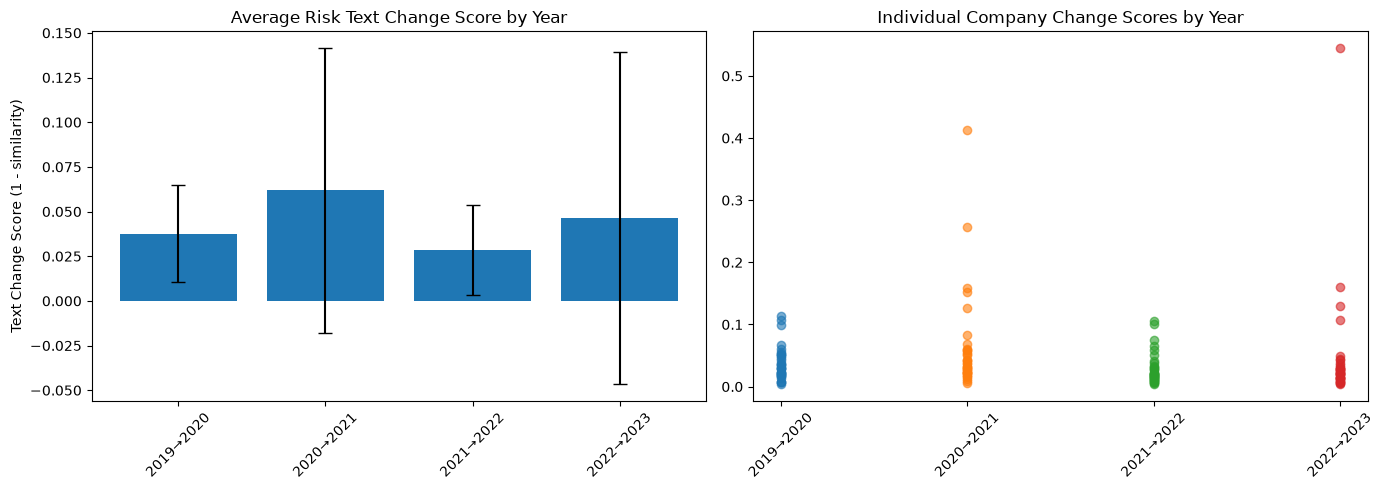

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

year_transitions = [f"{row.year_from}→{row.year_to}" for row in avg_change_by_year.reset_index().itertuples()]
axes[0].bar(year_transitions, avg_change_by_year["mean"], yerr=avg_change_by_year["std"], capsize=5)
axes[0].set_title("Average Risk Text Change Score by Year")
axes[0].set_ylabel("Text Change Score (1 - similarity)")
axes[0].tick_params(axis='x', rotation=45)

for transition, group in change_df.groupby(["year_from", "year_to"]):
    label = f"{transition[0]}→{transition[1]}"
    axes[1].scatter([label] * len(group), group["text_change_score"], alpha=0.6)
axes[1].set_title("Individual Company Change Scores by Year")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("../data/processed/risk_change_by_year.png", dpi=150)
plt.show()
                                                                                                  

### BBBY's risk language over time
Bed Bath & Beyond filed for bankruptcy in 2023. Checking whether its risk 
language shows a visible pattern leading up to that.

In [71]:
bbby_trajectory = results_df_sorted[results_df_sorted["ticker"] == "BBBY"][
    ["filing_year", "risk_text_length"]
]
print(bbby_trajectory)

bbby_changes = change_df[change_df["ticker"] == "BBBY"]
print("\nYear-over-year changes:")
print(bbby_changes[["year_from", "year_to", "word_count_change_pct", "text_change_score"]])

    filing_year  risk_text_length
20         2019             19029
21         2020             29134
22         2021             35985
23         2022             50585
24         2023             27534

Year-over-year changes:
    year_from  year_to  word_count_change_pct  text_change_score
16       2019     2020              54.686934           0.043258
17       2020     2021              26.321947           0.413511
18       2021     2022              39.173921           0.050148
19       2022     2023             -43.638541           0.544706


In [72]:
change_df.to_csv("../data/processed/risk_change_metrics.csv", index=False)
print("Saved risk change metrics")

Saved risk change metrics


### Pulling stock price data
For each company and filing year, we need the stock's realized volatility 
in the months following the filing date, so we can test whether risk 
language change actually predicted what happened to the stock afterward.

### Getting exact filing dates
We need the real filing date for each company-year, not just the year, 
since volatility has to be measured starting from the actual date the 
filing became public.

In [75]:
# We already have filing dates captured during extraction — let's pull them
# back in, since results_df currently only has filing_year, not the exact date
filing_dates = []

for ticker in company_df["ticker"]:
    try:
        company = Company(cik_fallbacks.get(ticker, ticker))
        filings = get_filings_in_range(company)
        for filing in filings:
            filing_dates.append({
                "ticker": ticker,
                "filing_year": filing.filing_date.year,
                "filing_date": filing.filing_date,
            })
    except Exception as e:
        print(f"{ticker}: FAILED — {e}")

filing_dates_df = pd.DataFrame(filing_dates)
filing_dates_df = filing_dates_df.drop_duplicates(subset=["ticker", "filing_year"], keep="first")
print(f"Total filing dates: {len(filing_dates_df)}")
filing_dates_df.head()

Total filing dates: 174


,ticker,filing_year,filing_date
0,WMT,2023,2023-03-17
1,WMT,2022,2022-03-18
2,WMT,2021,2021-03-19
3,WMT,2020,2020-03-20
4,WMT,2019,2019-03-28


### Computing realized volatility after each filing
For each company-year, pulling daily stock prices for the 60 trading days 
following the filing date and computing realized volatility from daily 
returns. This is the outcome we're testing risk-language change against.

In [77]:
import yfinance as yf

def compute_volatility_after_filing(ticker, filing_date, window_days=60):
    """
    Pulls daily price data starting from the filing date and computes
    annualized realized volatility over the following window_days trading days.
    """
    start = pd.Timestamp(filing_date)
    end = start + pd.Timedelta(days=window_days * 1.5)  # buffer for weekends/holidays

    try:
        hist = yf.download(ticker, start=start, end=end, progress=False, auto_adjust=True)
        if len(hist) < 10:  # not enough data to compute meaningful volatility
            return None

        hist = hist.iloc[:window_days]  # limit to the target number of trading days
        daily_returns = hist["Close"].pct_change().dropna()
        annualized_vol = daily_returns.std() * np.sqrt(252)  # 252 trading days/year

        return float(annualized_vol.iloc[0]) if hasattr(annualized_vol, 'iloc') else float(annualized_vol)
    except Exception:
        return None


# Test on one company first
test_vol = compute_volatility_after_filing("WMT", "2023-03-17")
print(f"WMT 2023 volatility test: {test_vol}")

WMT 2023 volatility test: 0.11251742722463634


### Computing volatility for all company-years
Running the volatility calculation across all 174 filings. Delisted 
companies (like BBBY) may not have data available for later periods, so 
we're tracking failures separately rather than letting them stop the run.

In [78]:
import time

# Some tickers changed or were delisted - use the same overrides as before,
# but yfinance needs the actual trading symbol, not always the SEC CIK
yfinance_ticker_overrides = {
    # BBBY was delisted after bankruptcy - historical data may still exist
    # under the old ticker for dates before delisting
}

volatility_results = []
volatility_failures = []

for _, row in filing_dates_df.iterrows():
    ticker = row["ticker"]
    filing_date = row["filing_date"]
    filing_year = row["filing_year"]

    yf_ticker = yfinance_ticker_overrides.get(ticker, ticker)

    vol = compute_volatility_after_filing(yf_ticker, filing_date)

    if vol is None:
        volatility_failures.append((ticker, filing_year, "no data or insufficient history"))
        continue

    volatility_results.append({
        "ticker": ticker,
        "filing_year": filing_year,
        "filing_date": filing_date,
        "realized_volatility": vol,
    })

    time.sleep(0.2)  # be reasonably polite to Yahoo Finance

print(f"\nTotal successful: {len(volatility_results)}")
print(f"Total failures: {len(volatility_failures)}")
if volatility_failures:
    print("\nFailures:")
    for f in volatility_failures:
        print(f"  {f}")

$JWN: possibly delisted; no timezone found

1 Failed download:
['JWN']: possibly delisted; no timezone found
$JWN: possibly delisted; no timezone found

1 Failed download:
['JWN']: possibly delisted; no timezone found
$JWN: possibly delisted; no timezone found

1 Failed download:
['JWN']: possibly delisted; no timezone found
$JWN: possibly delisted; no timezone found

1 Failed download:
['JWN']: possibly delisted; no timezone found
$JWN: possibly delisted; no timezone found

1 Failed download:
['JWN']: possibly delisted; no timezone found
$GPS: possibly delisted; no timezone found

1 Failed download:
['GPS']: possibly delisted; no timezone found
$GPS: possibly delisted; no timezone found

1 Failed download:
['GPS']: possibly delisted; no timezone found
$GPS: possibly delisted; no timezone found

1 Failed download:
['GPS']: possibly delisted; no timezone found
$GPS: possibly delisted; no timezone found

1 Failed download:
['GPS']: possibly delisted; no timezone found
$GPS: possibly deli


Total successful: 153
Total failures: 21

Failures:
  ('JWN', 2023, 'no data or insufficient history')
  ('JWN', 2022, 'no data or insufficient history')
  ('JWN', 2021, 'no data or insufficient history')
  ('JWN', 2020, 'no data or insufficient history')
  ('JWN', 2019, 'no data or insufficient history')
  ('GPS', 2023, 'no data or insufficient history')
  ('GPS', 2022, 'no data or insufficient history')
  ('GPS', 2021, 'no data or insufficient history')
  ('GPS', 2020, 'no data or insufficient history')
  ('GPS', 2019, 'no data or insufficient history')
  ('BBBY', 2023, 'no data or insufficient history')
  ('BBBY', 2022, 'no data or insufficient history')
  ('BBBY', 2021, 'no data or insufficient history')
  ('BBBY', 2020, 'no data or insufficient history')
  ('BBBY', 2019, 'no data or insufficient history')
  ('ACI', 2019, 'no data or insufficient history')
  ('WBA', 2023, 'no data or insufficient history')
  ('WBA', 2022, 'no data or insufficient history')
  ('WBA', 2021, 'no data

In [79]:
import yfinance as yf

for ticker in ["JWN", "GPS", "WBA"]:
    try:
        test = yf.download(ticker, start="2023-01-01", end="2023-02-01", progress=False, auto_adjust=True)
        print(f"{ticker}: {len(test)} rows returned")
    except Exception as e:
        print(f"{ticker}: error — {e}")

$JWN: possibly delisted; no timezone found

1 Failed download:
['JWN']: possibly delisted; no timezone found


JWN: 0 rows returned


$GPS: possibly delisted; no timezone found

1 Failed download:
['GPS']: possibly delisted; no timezone found
$WBA: possibly delisted; no timezone found

1 Failed download:
['WBA']: possibly delisted; no timezone found


GPS: 0 rows returned
WBA: 0 rows returned



### Trying stooq as a fallback for delisted tickers
Yahoo Finance drops historical data for companies that later delisted or 
went private. Stooq sometimes retains this data since it archives 
differently. Testing on our four problem tickers before committing to it.

In [81]:
import pandas_datareader.data as web

for ticker in ["JWN", "GPS", "WBA", "BBBY"]:
    try:
        test = web.DataReader(ticker, "stooq", start="2023-01-01", end="2023-02-01")
        print(f"{ticker}: {len(test)} rows returned")
        if len(test) > 0:
            print(test.head(2))
    except Exception as e:
        print(f"{ticker}: error — {e}")
    print()

JWN: error — data_source='stooq' is not implemented

GPS: error — data_source='stooq' is not implemented

WBA: error — data_source='stooq' is not implemented

BBBY: error — data_source='stooq' is not implemented



### Trying Stooq's direct CSV endpoint instead
The pandas-datareader wrapper doesn't support Stooq in this version. Stooq 
also offers a simple direct CSV download, so trying that instead.

In [83]:
import requests
import io

def get_stooq_data(ticker, start, end):
    """Fetch historical daily data directly from Stooq's CSV endpoint."""
    url = f"https://stooq.com/q/d/l/?s={ticker}.us&d1={start}&d2={end}&i=d"
    response = requests.get(url)
    if response.status_code == 200 and "Date" in response.text:
        return pd.read_csv(io.StringIO(response.text))
    return None

for ticker in ["JWN", "GPS", "WBA", "BBBY"]:
    result = get_stooq_data(ticker, "20230101", "20230201")
    if result is not None and len(result) > 0:
        print(f"{ticker}: {len(result)} rows returned")
        print(result.head(2))
    else:
        print(f"{ticker}: no data")
    print()

JWN: no data

GPS: no data

WBA: no data

BBBY: no data



### Finalizing the volatility dataset
JWN, GPS, WBA, and BBBY were later delisted, taken private, or went 
bankrupt, and no accessible free data source retains their historical 
pricing from the free providers checked. These four are excluded from the 
volatility analysis specifically, though their risk-language data remains 
valid and usable elsewhere.

In [84]:
volatility_df = pd.DataFrame(volatility_results)
print(f"Total company-years with volatility data: {len(volatility_df)}")
print(f"Companies included: {volatility_df['ticker'].nunique()}")

excluded_tickers = set(company_df["ticker"]) - set(volatility_df["ticker"])
print(f"\nExcluded companies: {excluded_tickers}")

volatility_df.to_csv("../data/processed/volatility_data.csv", index=False)
print(f"\nSaved to data/processed/volatility_data.csv")

Total company-years with volatility data: 153
Companies included: 31

Excluded companies: {'BBBY', 'WBA', 'JWN', 'GPS'}

Saved to data/processed/volatility_data.csv


### Merging risk-language change with volatility outcomes
Joining the year-over-year risk change scores with the volatility measured 
after the LATER of the two years in each comparison, since that's the 
filing whose aftermath we're measuring.

In [85]:
# For each change_df row (year_from -> year_to), we want the volatility
# that followed the year_to filing, since that's the filing whose
# aftermath we're measuring
merged_df = change_df.merge(
    volatility_df[["ticker", "filing_year", "realized_volatility"]],
    left_on=["ticker", "year_to"],
    right_on=["ticker", "filing_year"],
    how="inner"
)

merged_df = merged_df.drop(columns=["filing_year"])

print(f"Merged dataset: {len(merged_df)} rows")
print(f"Companies included: {merged_df['ticker'].nunique()}")
merged_df.head(10)

Merged dataset: 123 rows
Companies included: 31


,ticker,year_from,year_to,word_count_change_pct,text_similarity,text_change_score,realized_volatility
0,ACI,2019,2020,32.327343,0.932875,0.067125,0.312116
1,ACI,2020,2021,37.601435,0.742539,0.257461,0.299123
2,ACI,2021,2022,-4.090881,0.969346,0.030654,0.362086
3,ACI,2022,2023,-20.000000,0.871006,0.128994,0.100917
4,AEO,2019,2020,7.981410,0.963702,0.036298,1.230149
5,AEO,2020,2021,26.459581,0.941283,0.058717,0.472650
6,AEO,2021,2022,53.714117,0.940573,0.059427,0.638408
7,AEO,2022,2023,-2.849442,0.977309,0.022691,0.526811
8,ANF,2019,2020,19.238593,0.887066,0.112934,0.981026
9,ANF,2020,2021,37.862540,0.968294,0.031706,0.513972


In [86]:
merged_df.to_csv("../data/processed/risk_volatility_merged.csv", index=False)
print(f"Saved {len(merged_df)} rows to data/processed/risk_volatility_merged.csv")

Saved 123 rows to data/processed/risk_volatility_merged.csv


### Does risk-language change relate to volatility at all?
Plotting text change score against realized volatility before running any 
formal statistical test, to see if there's a visible pattern.

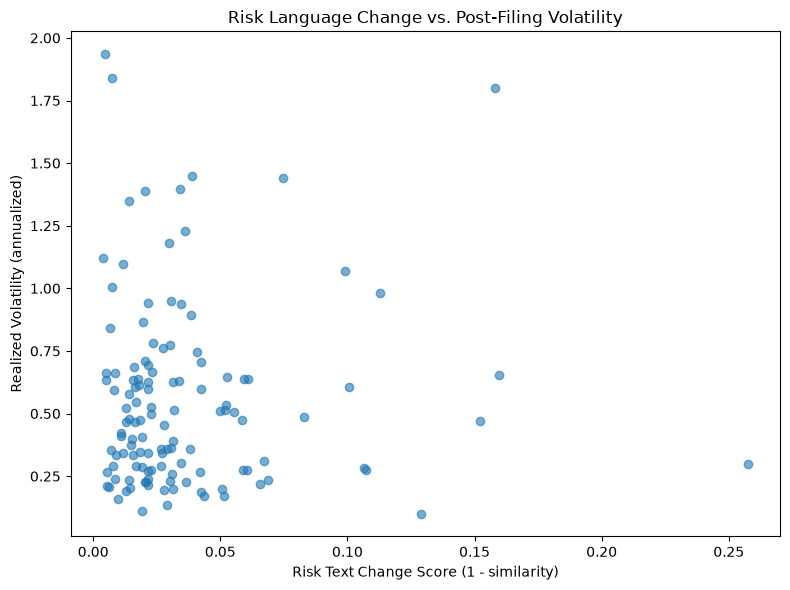

Correlation (text_change_score vs. volatility): 0.0282
Correlation (|word count change %| vs. volatility): 0.1334


In [87]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(merged_df["text_change_score"], merged_df["realized_volatility"], alpha=0.6)
ax.set_xlabel("Risk Text Change Score (1 - similarity)")
ax.set_ylabel("Realized Volatility (annualized)")
ax.set_title("Risk Language Change vs. Post-Filing Volatility")
plt.tight_layout()
plt.savefig("../data/processed/risk_vs_volatility_scatter.png", dpi=150)
plt.show()

correlation = merged_df["text_change_score"].corr(merged_df["realized_volatility"])
print(f"Correlation (text_change_score vs. volatility): {correlation:.4f}")

correlation_wc = merged_df["word_count_change_pct"].abs().corr(merged_df["realized_volatility"])
print(f"Correlation (|word count change %| vs. volatility): {correlation_wc:.4f}")

### Controlling for market-wide volatility
2020 filings likely show inflated volatility across almost every company 
due to the COVID market crash, which would hide any company-specific 
signal. Pulling S&P 500 volatility over the same windows and computing 
excess volatility to control for this.

In [88]:
def compute_market_volatility(filing_date, window_days=60):
    """Same volatility calculation, but for the S&P 500 index (^GSPC),
    used as the market-wide baseline to subtract out."""
    start = pd.Timestamp(filing_date)
    end = start + pd.Timedelta(days=window_days * 1.5)

    try:
        hist = yf.download("^GSPC", start=start, end=end, progress=False, auto_adjust=True)
        if len(hist) < 10:
            return None
        hist = hist.iloc[:window_days]
        daily_returns = hist["Close"].pct_change().dropna()
        annualized_vol = daily_returns.std() * np.sqrt(252)
        return float(annualized_vol.iloc[0]) if hasattr(annualized_vol, 'iloc') else float(annualized_vol)
    except Exception:
        return None


# Get unique filing dates first, since market volatility only depends on
# the date, not the company - no need to repeat this per company
unique_dates = volatility_df["filing_date"].unique()
market_vol_lookup = {}

for date in unique_dates:
    market_vol_lookup[date] = compute_market_volatility(date)

print(f"Computed market volatility for {len(market_vol_lookup)} unique filing dates")

Computed market volatility for 96 unique filing dates


### Computing excess volatility
Subtracting market-wide volatility from each company's realized volatility, 
isolating the company-specific component that risk-language change might 
actually predict.

In [89]:
volatility_df["market_volatility"] = volatility_df["filing_date"].map(market_vol_lookup)
volatility_df["excess_volatility"] = volatility_df["realized_volatility"] - volatility_df["market_volatility"]

print(f"Rows with missing market volatility: {volatility_df['market_volatility'].isna().sum()}")
print(volatility_df[["ticker", "filing_year", "realized_volatility", "market_volatility", "excess_volatility"]].head(10))

Rows with missing market volatility: 0
  ticker  filing_year  realized_volatility  market_volatility  \
0    WMT         2023             0.112517           0.126475   
1    WMT         2022             0.343917           0.271901   
2    WMT         2021             0.136154           0.114622   
3    WMT         2020             0.285363           0.405909   
4    WMT         2019             0.131961           0.116691   
5    TGT         2023             0.273410           0.143652   
6    TGT         2022             0.631058           0.260037   
7    TGT         2021             0.232982           0.120158   
8    TGT         2020             0.597260           0.569389   
9    TGT         2019             0.290620           0.122117   

   excess_volatility  
0          -0.013957  
1           0.072016  
2           0.021532  
3          -0.120546  
4           0.015270  
5           0.129758  
6           0.371022  
7           0.112824  
8           0.027871  
9           0.1

### Re-testing the relationship using excess volatility
Merging risk-language change with excess volatility instead of raw 
volatility, and checking whether the market-wide control reveals any 
signal that was hidden before.

Merged dataset: 123 rows
Correlation (text_change_score vs. EXCESS volatility): 0.0825
Correlation (|word count change %| vs. EXCESS volatility): 0.2012


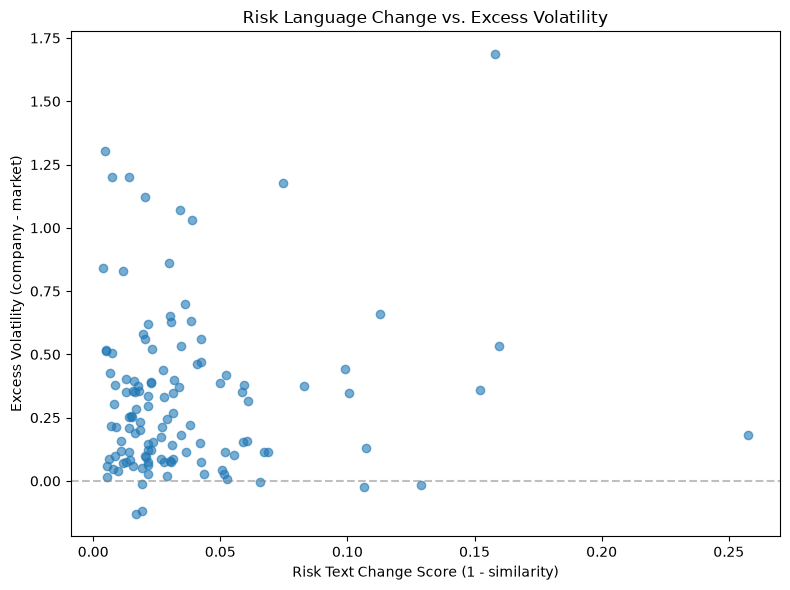

In [90]:
merged_df_v2 = change_df.merge(
    volatility_df[["ticker", "filing_year", "excess_volatility"]],
    left_on=["ticker", "year_to"],
    right_on=["ticker", "filing_year"],
    how="inner"
).drop(columns=["filing_year"])

print(f"Merged dataset: {len(merged_df_v2)} rows")

correlation_excess = merged_df_v2["text_change_score"].corr(merged_df_v2["excess_volatility"])
print(f"Correlation (text_change_score vs. EXCESS volatility): {correlation_excess:.4f}")

correlation_wc_excess = merged_df_v2["word_count_change_pct"].abs().corr(merged_df_v2["excess_volatility"])
print(f"Correlation (|word count change %| vs. EXCESS volatility): {correlation_wc_excess:.4f}")

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(merged_df_v2["text_change_score"], merged_df_v2["excess_volatility"], alpha=0.6)
ax.axhline(0, linestyle="--", color="gray", alpha=0.5)
ax.set_xlabel("Risk Text Change Score (1 - similarity)")
ax.set_ylabel("Excess Volatility (company - market)")
ax.set_title("Risk Language Change vs. Excess Volatility")
plt.tight_layout()
plt.savefig("../data/processed/risk_vs_excess_volatility_scatter.png", dpi=150)
plt.show()

### Checking statistical significance
Correlation alone doesn't tell us if this relationship is likely real or 
just noise given our sample size. Running a simple regression with a 
p-value to check.

In [91]:
from scipy import stats

slope, intercept, r_value, p_value, std_err = stats.linregress(
    merged_df_v2["word_count_change_pct"].abs(),
    merged_df_v2["excess_volatility"]
)

print(f"R-value: {r_value:.4f}")
print(f"R-squared: {r_value**2:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Slope: {slope:.6f}")

R-value: 0.2012
R-squared: 0.0405
P-value: 0.0257
Slope: 0.004754


In [92]:
merged_df_v2.to_csv("../data/processed/risk_volatility_final.csv", index=False)
print("Saved final merged dataset")

Saved final merged dataset


### Framing the business takeaway
Translating the statistical result into something an analyst or investor 
could actually act on.

In [93]:
# Using the regression slope to translate into a concrete, interpretable statement
# slope tells us: for each 1-percentage-point change in word count,
# excess volatility changes by this much
print(f"For every 10 percentage points of |word count change|, "
      f"excess volatility changes by approximately {slope * 10:.4f}")

# Put this in context - what's a "large" word count change in our data?
print(f"\nMedian |word count change|: {merged_df_v2['word_count_change_pct'].abs().median():.1f}%")
print(f"75th percentile |word count change|: {merged_df_v2['word_count_change_pct'].abs().quantile(0.75):.1f}%")
print(f"90th percentile |word count change|: {merged_df_v2['word_count_change_pct'].abs().quantile(0.90):.1f}%")

For every 10 percentage points of |word count change|, excess volatility changes by approximately 0.0475

Median |word count change|: 8.4%
75th percentile |word count change|: 16.9%
90th percentile |word count change|: 29.2%


### Exporting data for the dashboard
Saving the merged dataset and headline statistics so the Streamlit app can 
load instantly instead of recomputing anything.

In [95]:
import json

dashboard_data = merged_df_v2.copy()
dashboard_data.to_csv("../data/processed/dashboard_risk_volatility.csv", index=False)

company_trajectory = results_df_sorted.merge(
    volatility_df[["ticker", "filing_year", "realized_volatility", "excess_volatility"]],
    on=["ticker", "filing_year"],
    how="left"
)
company_trajectory[["ticker", "filing_year", "risk_text_length", "realized_volatility", "excess_volatility"]].to_csv(
    "../data/processed/dashboard_company_trajectory.csv", index=False
)

summary_stats = {
    "n_companies": int(merged_df_v2["ticker"].nunique()),
    "n_comparisons": int(len(merged_df_v2)),
    "correlation_text_change": float(correlation_excess),
    "correlation_word_count": float(correlation_wc_excess),
    "r_squared": float(r_value**2),
    "p_value": float(p_value),
    "slope": float(slope),
    "median_word_count_change": float(merged_df_v2["word_count_change_pct"].abs().median()),
    "p90_word_count_change": float(merged_df_v2["word_count_change_pct"].abs().quantile(0.90)),
    "excluded_companies": ["JWN", "GPS", "WBA", "BBBY"],
}

with open("../data/processed/dashboard_summary.json", "w") as f:
    json.dump(summary_stats, f, indent=2)

print("Exported dashboard data files")
print(summary_stats)

Exported dashboard data files
{'n_companies': 31, 'n_comparisons': 123, 'correlation_text_change': 0.08246672244964837, 'correlation_word_count': 0.20118700960294192, 'r_squared': 0.040476212832974236, 'p_value': 0.02565749480273028, 'slope': 0.004754473656290941, 'median_word_count_change': 8.447613823368075, 'p90_word_count_change': 29.181139441750013, 'excluded_companies': ['JWN', 'GPS', 'WBA', 'BBBY']}
